# Pandas for Exploration and Cleaning

In [1]:
import pandas as pd

df = pd.read_csv('ComputerSales.csv')
print(df.head())

   Sale ID      Contact Sex  Age State Product ID Product Type  Sale Price  \
0        1  Paul Thomas   M   43    OH  M01-F0024      Desktop      479.99   
1        2  Margo Simms   F   37    WV  GT13-0024      Desktop     1249.99   
2        3    Sam Stine   M   26    PA      I3670      Desktop      649.99   
3        4   Moe Eggert   M   35    PA      I3593       Laptop      399.99   
4        5  Jessica Elk   F   55    PA     15M-ED       Laptop      699.99   

   Profit     Lead     Month  Year  
0  143.39  Website   January  2018  
1  230.89  Flyer 4   January  2018  
2  118.64  Website  February  2018  
3   72.09  Website     March  2018  
4   98.09  Flyer 4     March  2018  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sale ID       39 non-null     int64  
 1   Contact       39 non-null     object 
 2   Sex           39 non-null     object 
 3   Age           39 non-null     int64  
 4   State         39 non-null     object 
 5   Product ID    39 non-null     object 
 6   Product Type  39 non-null     object 
 7   Sale Price    39 non-null     float64
 8   Profit        39 non-null     float64
 9   Lead          39 non-null     object 
 10  Month         39 non-null     object 
 11  Year          39 non-null     int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 3.8+ KB
None


In [ ]:
print(df.isnull().sum())

# you would use df = df.drop('irrelevant_column_1', axis=1)
# if there was a column that was irrelevant
# making it cleaner 
# use it cautiously if it could be important later on
# use df.dropna() to keep your columns

Sale ID         0
Contact         0
Sex             0
Age             0
State           0
Product ID      0
Product Type    0
Sale Price      0
Profit          0
Lead            0
Month           0
Year            0
dtype: int64


In [8]:
print(df['Sale Price'].mean())

837.1694871794879


# Update the Data

In [ ]:
# df['date'] = pd.to_datetime(df['date'])

# Aggregate the DataFrame

In [10]:
sales_by_product = df.groupby('Product ID')['Profit'].sum()
print(sales_by_product)

Product ID
15M-ED        392.36
81TC00        611.70
GA401IV      1082.04
GT13-0024     923.56
I3593         360.45
I3670         355.92
M01-F0024     716.95
MY2J2LL       586.76
Q526FA        429.27
Name: Profit, dtype: float64


# Create Profit Column

In [12]:
df = df.dropna()
df['price'] = [ int(float(x)) for x in df['Sale Price']]
df['profit'] = [ int(float(x)) for x in df['Profit']]

df['cost'] = df['price'] - df['profit']

print(df['profit'].mean())
print(df['profit'].median())
print(df.describe())

139.5897435897436
143.0
         Sale ID        Age   Sale Price      Profit         Year  \
count  39.000000  39.000000    39.000000   39.000000    39.000000   
mean   20.000000  45.666667   837.169487  139.974615  2018.871795   
std    11.401754   9.820315   342.229138   44.746575     0.800641   
min     1.000000  23.000000   399.990000   72.090000  2018.000000   
25%    10.500000  43.000000   564.990000  118.640000  2018.000000   
50%    20.000000  46.000000   699.990000  143.090000  2019.000000   
75%    29.500000  53.000000  1149.990000  163.515000  2019.500000   
max    39.000000  57.000000  1349.990000  230.890000  2020.000000   

             price      profit         cost  
count    39.000000   39.000000    39.000000  
mean    836.179487  139.589744   696.589744  
std     342.229138   44.561441   306.935508  
min     399.000000   72.000000   327.000000  
25%     564.000000  118.000000   431.500000  
50%     699.000000  143.000000   601.000000  
75%    1149.000000  163.000000  

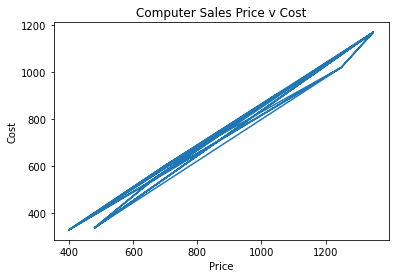

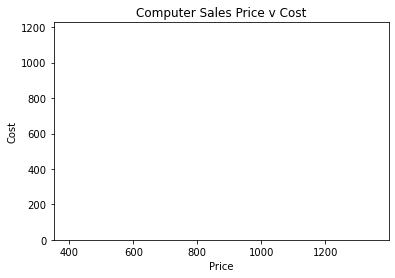

In [13]:
import matplotlib.pyplot as plt

# Line Chart
x = df['price']
y = df['cost']

plt.plot(x, y)
plt.title("Computer Sales Price v Cost")
plt.xlabel("Price")
plt.ylabel("Cost")
plt.show()

# Bar Chart

plt.bar(x, y)
plt.title("Computer Sales Price v Cost")
plt.xlabel("Price")
plt.ylabel("Cost")
plt.show()